/data/Sapan_grad_proj/TOAs/tim_files/backup/final_result_ppt

In [ ]:
# Residual PLots for Paper

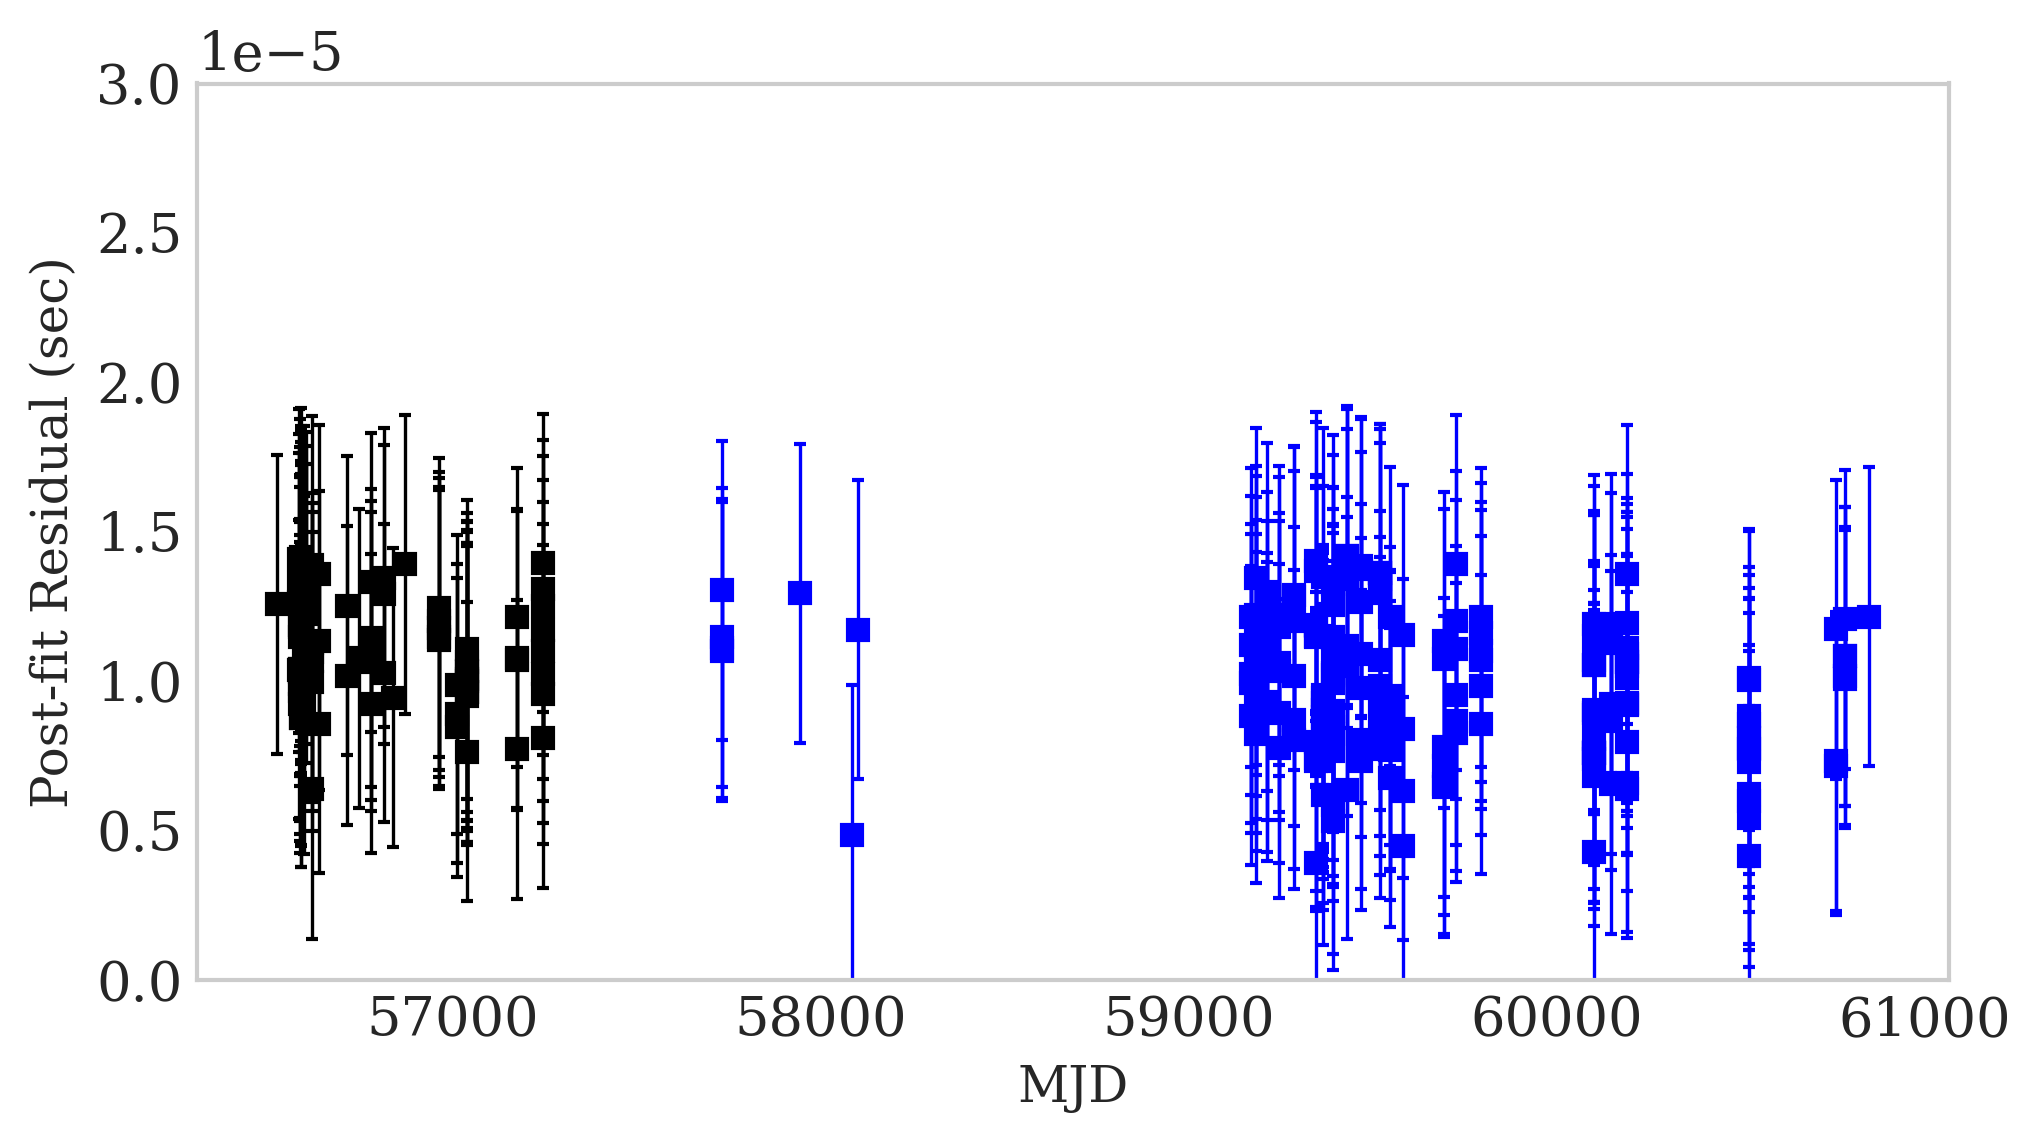

In [9]:
import pandas as pd
import matplotlib.pyplot as plt

# === Load the timing file ===
file = "J0248_GSB_GWB.csv"

# Adjust depending on your file format (space-separated)
df = pd.read_csv(file, delim_whitespace=True, header=None,
                 names=['Backend', 'Freq_MHz', 'MJD', 'Residual_us', 'Flag'])

# Convert residuals to seconds (since your plot is in sec)
df['Residual_s'] = df['Residual_us'] * 1e-6

# === Parameters you can customize ===
ymin, ymax = 0e-5, 3e-5        # Y-axis limits
color_before = 'k'              # Color before split MJD (black)
color_after = 'blue'            # Color after split MJD (blue)
split_mjd = 57700               # MJD where color changes
marker_size = 30                # Square size

# Optional: define a constant error (if none in file)
# df['Error_s'] = df['Residual_us'] * 0.1e-6  # example
df['Error_s'] = 5e-6  # example 5 microseconds constant error

# === Apply color condition ===
df['Color'] = df['MJD'].apply(lambda x: color_before if x < split_mjd else color_after)

# === Plot ===
plt.figure(figsize=(7, 4))
for color, group in df.groupby('Color'):
    plt.errorbar(group['MJD'], group['Residual_s'], yerr=group['Error_s'],
                 fmt='s', color=color, markersize=5,
                 elinewidth=0.8, capsize=1.5, alpha=1.0)

plt.axhline(0, color='gray', lw=0.7)
plt.xlabel("MJD", fontsize=12)
plt.ylabel("Post-fit Residual (sec)", fontsize=12)
plt.ylim(ymin, ymax)
plt.grid(False)
plt.tight_layout()
plt.show()
